## Simple linear regression implementation

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Weight vs height')

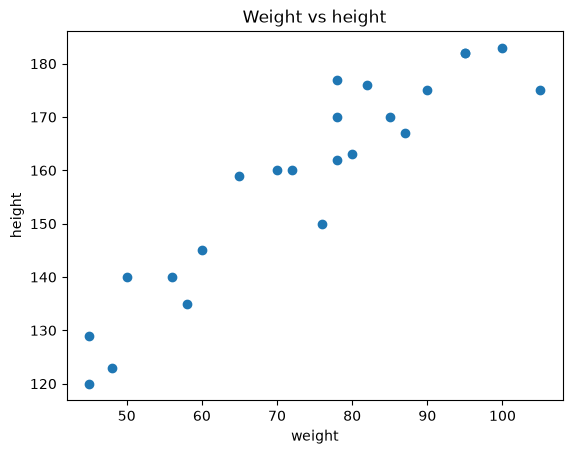

In [6]:
##Scatter plot of height and weight

plt.scatter(df['Weight'],df['Height'])
plt.xlabel('weight')
plt.ylabel('height')
plt.title('Weight vs height')


In [7]:
##corr
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


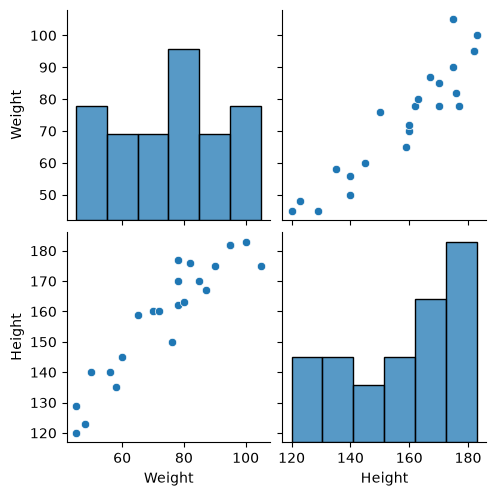

In [8]:
import seaborn as sns
sns.pairplot(df)

In [13]:
## linear regression using sklearn

x= df[['Weight']] ## indepent feature must be in data frame or 2d array

y= df['Height'] ## dependent feature

In [14]:
x.shape

(23, 1)

In [15]:
x



,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [16]:
!pip install scikit-learn


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 171.2 kB/s eta 0:00:45
   ------ --------------------------------- 1.3/8.2 MB 568.6 kB/s eta 0:00:13
   ---------- ----------------------------- 2.1/8.2 MB 903.5 kB/s eta 0:00:07
   -------------- ------------------------- 2.9/8.2 MB 1.2 MB/s eta 0:00:05
   ---

In [18]:
from sklearn.model_selection import train_test_split




In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)


In [26]:
x_train



array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [24]:
## standardize the data
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



In [28]:
## apply linear regression

from sklearn.linear_model import LinearRegression

In [29]:
regression = LinearRegression()

In [30]:
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


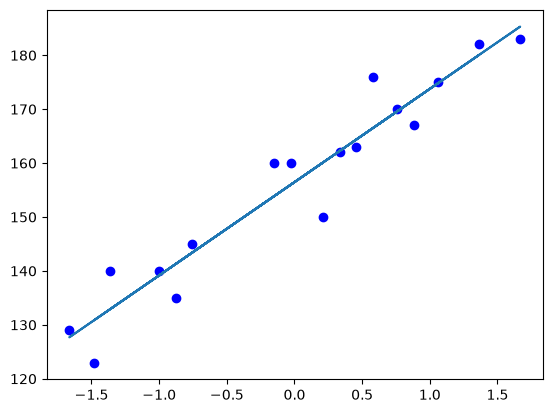

In [32]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train,regression.predict(x_train))


In [36]:
y_pred = regression.predict(x_test)

In [34]:
# performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score




In [37]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
RMSE = np.sqrt(mse)
print('Mean Squared Error:',mse)
print('Mean Absolute Error:',mae)   
print('Root Mean Squared Error:',RMSE)


Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605


In [38]:
score = r2_score(y_test,y_pred)
print('R2 score:',score)


R2 score: 0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables


In [40]:
## adjusted r2 suare 
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)


0.6701033397476595

In [42]:
!pip install statsmodels



   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 4.8 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.5 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.5 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 4.3 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 4.3 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 4.3 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.2 MB/s  0:00:02

   ---------------------------------------- 0/2 [patsy]
   --------------------------------------

In [43]:
import statsmodels.api as sm


In [44]:
MODEL = sm.OLS(y_train, x_train).fit()


In [45]:
predictions = MODEL.predict(x_test)
print(predictions)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [ ]:
print(MODEL.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 05 Jul 2026   Prob (F-statistic):                       0.664
Time:                        09:04:11   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

: 